CELL 1 — Import Libraries

In [ ]:
# Libraries are pre-built tools that save us from writing everything ourselves

import pandas as pd          # for loading and working with data (like Excel in Python)
import numpy as np           # for math/number operations
import matplotlib.pyplot as plt  # for drawing charts
import seaborn as sns        # nicer-looking charts built on top of matplotlib
import warnings
warnings.filterwarnings('ignore')  # hide minor warnings so output looks cleaner

print("Libraries loaded!")

Libraries loaded!


CELL 2 — Load the Dataset

In [ ]:
# pd.read_csv() reads a CSV file and stores it as a DataFrame (like a table)
df = pd.read_csv('Telco_Cusomer_Churn.csv')

# .shape tells you (rows, columns)
print("Shape:", df.shape)

# .head() shows the first 5 rows
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


CELL 3 — Understand Data

In [ ]:
# .info() shows column names, data types, and non-null counts
df.info()

# .describe() gives statistics for number columns (mean, min, max, etc.)
df.describe()

# Check for missing values in each column
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

CELL 4 — Explore the Target Column (Churn)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


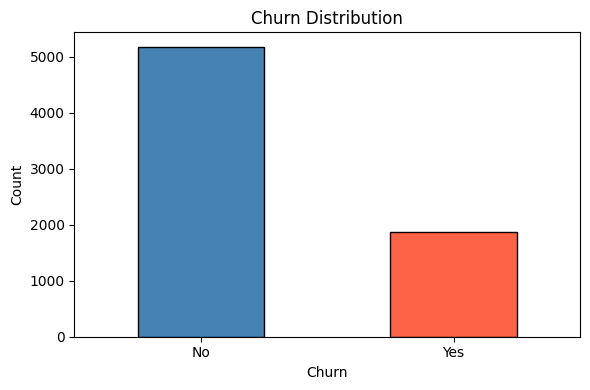

In [ ]:
# Count how many Yes/No in the Churn column
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)  # as percentages

# Visualise it
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

CELL 5 — Explore Key Features (EDA)

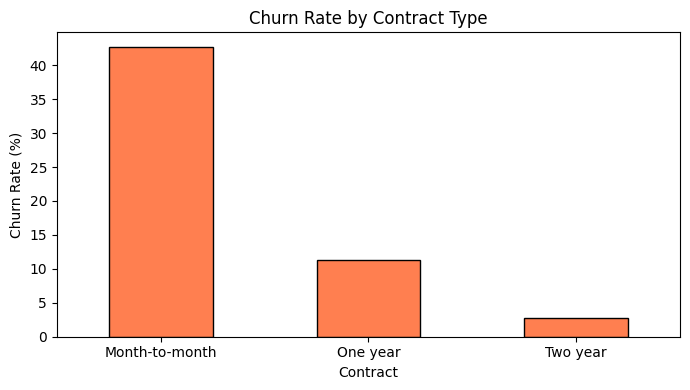

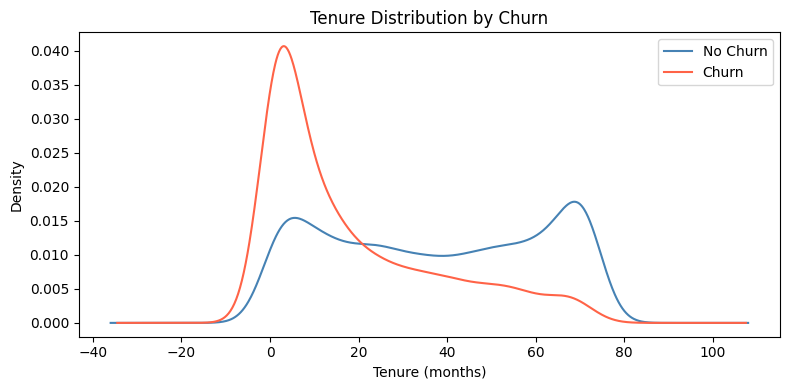

In [ ]:
# Churn rate by Contract type — one of the most important features
plt.figure(figsize=(7, 4))
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
contract_churn.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Distribution of tenure (how long customers stay) vs Churn
plt.figure(figsize=(8, 4))
df[df['Churn'] == 'No']['tenure'].plot(kind='kde', label='No Churn', color='steelblue')
df[df['Churn'] == 'Yes']['tenure'].plot(kind='kde', label='Churn', color='tomato')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.legend()
plt.tight_layout()
plt.show()

Cell 7  → Fix TotalCharges

In [ ]:
# TotalCharges is stored as text (object), convert it to number
# Any blank/empty string becomes NaN automatically
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check how many NaN appeared
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

# These 11 rows are new customers (tenure = 0, never been billed)
# So we fill with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("After fix:", df["TotalCharges"].isnull().sum(), "missing values")
print("✅ TotalCharges fixed!")

Missing TotalCharges: 11
After fix: 0 missing values
✅ TotalCharges fixed!


Cell 8  → Drop customerID

In [ ]:
# customerID is just a unique ID number, it doesn't help predict churn
df = df.drop(columns=["customerID"])

print("New shape:", df.shape)
print("✅ customerID removed!")

New shape: (7043, 20)
✅ customerID removed!


Cell 9  → Encode Churn

In [ ]:
# Machine learning models only understand numbers, not text
# So we convert: Yes → 1, No → 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df["Churn"].value_counts())
print("✅ Churn encoded!")

Churn
0    5174
1    1869
Name: count, dtype: int64
✅ Churn encoded!


Cell 10 → Encode text columns

In [ ]:
# Binary columns (only 2 possible values) → simple 1/0 mapping
binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

df["gender"] = df["gender"].map({"Male": 1, "Female": 0})
df["Partner"] = df["Partner"].map({"Yes": 1, "No": 0})
df["Dependents"] = df["Dependents"].map({"Yes": 1, "No": 0})
df["PhoneService"] = df["PhoneService"].map({"Yes": 1, "No": 0})
df["PaperlessBilling"] = df["PaperlessBilling"].map({"Yes": 1, "No": 0})

print("✅ Binary columns encoded!")

# Multi-value columns → One-Hot Encoding
# This creates a new column for each possible value
multi_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
]

df = pd.get_dummies(df, columns=multi_cols)

print("New shape after encoding:", df.shape)
print("✅ Multi-value columns encoded!")

✅ Binary columns encoded!
New shape after encoding: (7043, 41)
✅ Multi-value columns encoded!


## Cell 11 → Train/test split FIRST, then scale

**Why order matters:** if we scale (fit `StandardScaler`) on the whole dataset and *then* split into train/test, the scaler has already "seen" the test rows when it computed its mean/std. That's data leakage — the test set is supposed to be completely untouched until evaluation.

So we split first, fit the scaler on `X_train` only, then use that same fitted scaler to transform `X_test`. This matches `shared/preprocessing.py`, which the other members' scripts rely on.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X = all columns except Churn (the inputs), y = Churn (what we predict)
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Split BEFORE scaling — stratify=y keeps the same 73/27 churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit the scaler on TRAIN ONLY, then apply it to both — no leakage
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"Features:      {X_train.shape[1]} columns")
print("✅ Split done, scaler fit on train only!")


Training set:  5634 rows
Test set:      1409 rows
Features:      40 columns
✅ Split done, scaler fit on train only!


## Cell 12 → What does KNN actually do?

K-Nearest Neighbors doesn't really "learn" a formula the way Logistic Regression does. Instead, at prediction time it:

1. Takes the new customer you want to predict for
2. Measures the **distance** from that customer to every customer in the training set (usually Euclidean distance)
3. Finds the **k closest** training customers (the "neighbors")
4. Takes a **majority vote** of their labels (Churn / No Churn) — whichever label wins among the neighbors is the prediction

Below is a small, simplified 2D demo using just two features (`tenure` and `MonthlyCharges`) so you can actually *see* the neighbors being picked, before we run KNN on the real, full-feature dataset.

Query customer's 7 nearest neighbors voted: [0, 0, 0, 0, 0, 0, 0]
Fraction voting 'Churn': 0.00  →  Predicted: No Churn
Actual label: No Churn


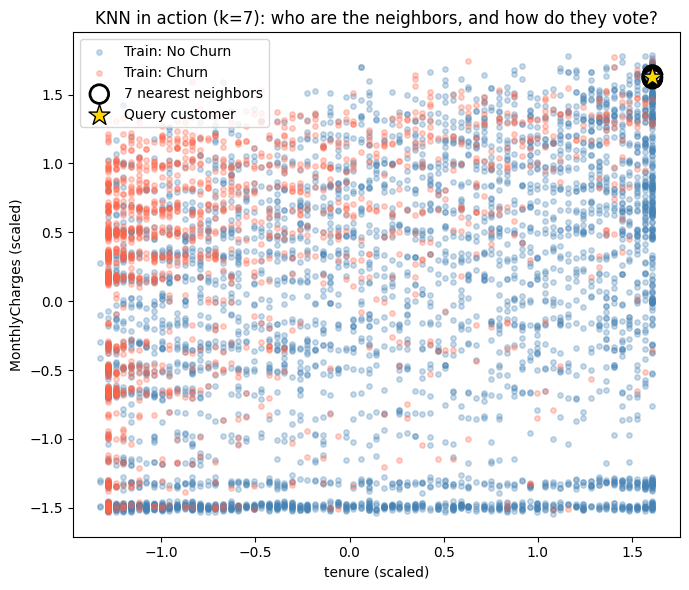

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Use just 2 (already-scaled) features so we can plot this in 2D
demo_features = ["tenure", "MonthlyCharges"]
X_demo = X_train[demo_features].values
y_demo = y_train.values

# Pick one real test customer as our "query point"
query_idx = 0
query_point = X_test[demo_features].values[query_idx].reshape(1, -1)
actual_label = y_test.values[query_idx]

k = 7
finder = NearestNeighbors(n_neighbors=k)
finder.fit(X_demo)
distances, neighbor_idx = finder.kneighbors(query_point)

neighbor_labels = y_demo[neighbor_idx[0]]
vote = neighbor_labels.mean()  # fraction of neighbors that churned
prediction = 1 if vote >= 0.5 else 0

print(f"Query customer's {k} nearest neighbors voted: {neighbor_labels.tolist()}")
print(f"Fraction voting 'Churn': {vote:.2f}  →  Predicted: {'Churn' if prediction else 'No Churn'}")
print(f"Actual label: {'Churn' if actual_label else 'No Churn'}")

# Plot it
plt.figure(figsize=(7, 6))
plt.scatter(X_demo[y_demo == 0, 0], X_demo[y_demo == 0, 1],
            c="steelblue", alpha=0.3, label="Train: No Churn", s=15)
plt.scatter(X_demo[y_demo == 1, 0], X_demo[y_demo == 1, 1],
            c="tomato", alpha=0.3, label="Train: Churn", s=15)
plt.scatter(X_demo[neighbor_idx[0], 0], X_demo[neighbor_idx[0], 1],
            facecolors="none", edgecolors="black", s=180, linewidths=2,
            label=f"{k} nearest neighbors")
plt.scatter(query_point[0, 0], query_point[0, 1], c="gold", edgecolors="black",
            s=250, marker="*", label="Query customer", zorder=5)
plt.xlabel("tenure (scaled)")
plt.ylabel("MonthlyCharges (scaled)")
plt.title(f"KNN in action (k={k}): who are the neighbors, and how do they vote?")
plt.legend()
plt.tight_layout()
plt.show()


## Cell 13 → Why scaling matters for KNN

KNN picks neighbors purely by distance. If `TotalCharges` (which can be in the thousands) were left unscaled next to something like `SeniorCitizen` (0 or 1), `TotalCharges` alone would dominate every distance calculation — the model would basically ignore every other feature. That's why we scaled `tenure`, `MonthlyCharges`, and `TotalCharges` with `StandardScaler` before doing anything distance-based. (The one-hot encoded columns are already 0/1, so they're on a comparable scale already.)

## Cell 14 → Train a baseline KNN model

Now let's fit a real KNN classifier on the full feature set (not just the 2 demo features) and see how it performs out of the box, with an arbitrary starting `k=5`.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print(f"KNN (k=5) Accuracy: {knn_accuracy:.4f}")
print(f"KNN (k=5) F1 score: {knn_f1:.4f}")
print("---")
print(classification_report(y_test, knn_pred, target_names=["No Churn", "Churn"]))
print("✅ Baseline KNN done!")


KNN (k=5) Accuracy: 0.7622
KNN (k=5) F1 score: 0.5430
---
              precision    recall  f1-score   support

    No Churn       0.83      0.85      0.84      1035
       Churn       0.55      0.53      0.54       374

    accuracy                           0.76      1409
   macro avg       0.69      0.69      0.69      1409
weighted avg       0.76      0.76      0.76      1409

✅ Baseline KNN done!


## Cell 15 → How does performance change with k?

`k` is the main knob for KNN. A very small `k` (like 1) follows the training data very closely and can overfit to noise. A very large `k` smooths things out but can blur the boundary between classes and hurt recall on the minority (Churn) class. Let's sweep across a range of `k` values and look at both **accuracy** and **F1** (F1 matters more here since churn is imbalanced ~27%/73%).

 k  Accuracy       F1
 1  0.725337 0.496749
 3  0.760114 0.548128
 5  0.762243 0.542974
 7  0.770759 0.559345
 9  0.777857 0.572988
11  0.777857 0.569464
15  0.779276 0.576871
21  0.779986 0.577657
31  0.779986 0.581081
41  0.783534 0.585034


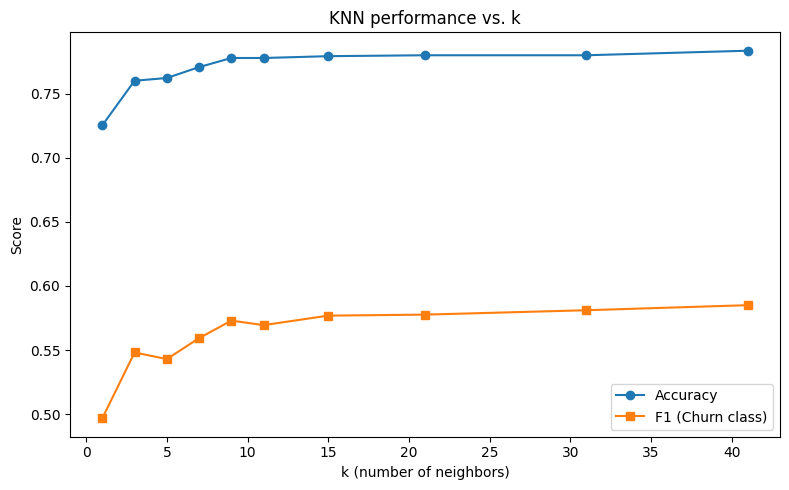


✅ Best k by F1 in this quick sweep: k=41


In [ ]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 41]
acc_scores, f1_scores = [], []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc_scores.append(accuracy_score(y_test, pred))
    f1_scores.append(f1_score(y_test, pred))

results_df = pd.DataFrame({"k": k_values, "Accuracy": acc_scores, "F1": f1_scores})
print(results_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(k_values, acc_scores, marker="o", label="Accuracy")
plt.plot(k_values, f1_scores, marker="s", label="F1 (Churn class)")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Score")
plt.title("KNN performance vs. k")
plt.legend()
plt.tight_layout()
plt.show()

best_k = k_values[int(np.argmax(f1_scores))]
print(f"\n✅ Best k by F1 in this quick sweep: k={best_k}")


## Cell 16 → Confusion matrix & ROC curve for the best k found above

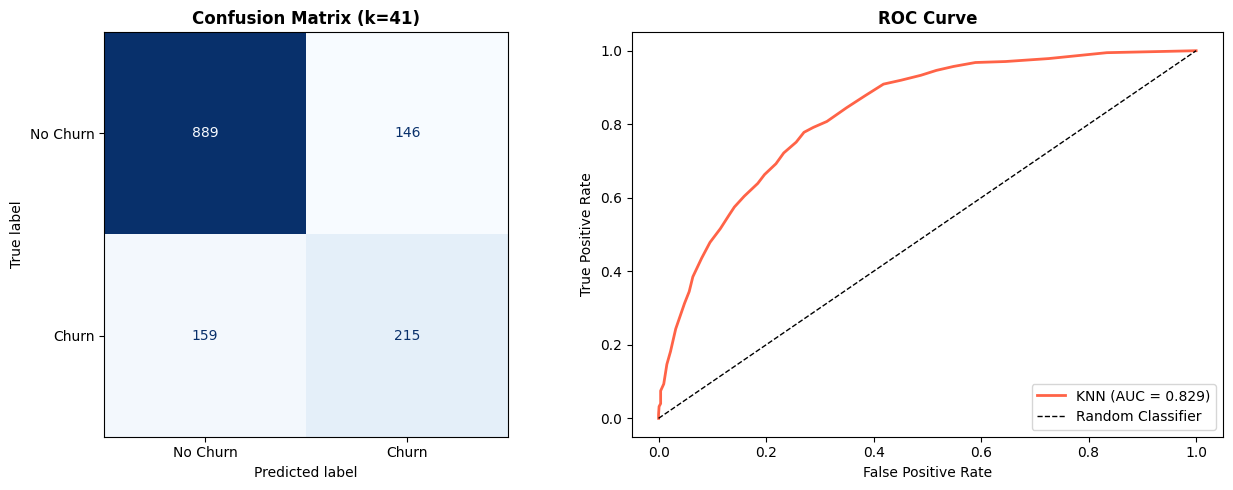

✅ KNN evaluation done!


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve, roc_auc_score

best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)
best_pred = best_knn.predict(X_test)
best_prob = best_knn.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title(f"Confusion Matrix (k={best_k})", fontweight="bold")

fpr, tpr, _ = roc_curve(y_test, best_prob)
auc = roc_auc_score(y_test, best_prob)
axes[1].plot(fpr, tpr, linewidth=2, color="tomato", label=f"KNN (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()
print("✅ KNN evaluation done!")


## Notes — this notebook vs. `member1_KNN/KNN.py`

This notebook is a **before-training sandbox** to build intuition for what KNN does and how sensitive it is to `k` — it is *not* the model used in the app or the report.

The real, graded KNN baseline lives in `member1_KNN/KNN.py`, and goes further than this notebook in three ways:

1. **Proper tuning** — `GridSearchCV` (5-fold, scored by F1) searches over `n_neighbors`, `weights` (uniform vs. distance-weighted), and `p` (Manhattan vs. Euclidean distance), instead of the plain accuracy/F1 sweep above.
2. **Threshold tuning for recall** — because `KNeighborsClassifier` has no `class_weight` option to handle the 73/27 imbalance, the script instead shifts the 0.5 decision threshold (using only training-set, out-of-fold probabilities) to guarantee at least 70% recall on churners.
3. **Shared data** — it loads `shared/processed/` (the exact same train/test split every other member uses) instead of re-doing the split here, so the final comparison in `results/compare_models.py` is fair.

Once you're comfortable with what's happening above, run the real thing:

```bash
python shared/preprocessing.py   # if not already run
python member1_KNN/KNN.py
```